# Статистическое исследование: Влияние инфляции и экономических факторов на субъективное ощущение счастья

## Постановка задачи

**Исследовательский вопрос:** Влияет ли уровень инфляции и экономическое благосостояние (ВВП на душу населения) на субъективное ощущение счастья в стране?

**Данные:** Объединённый датасет World Happiness Report + World Bank Inflation Data за 2019 год (137 стран).

**Три выборки:**
1. **Happiness Score** — индекс счастья (от 0 до 10), данные Gallup World Poll
2. **Headline Consumer Price Inflation** — инфляция потребительских цен (%), данные МВФ/Всемирного банка
3. **GDP per Capita** — ВВП на душу населения (нормированный индекс), данные Всемирного банка

**Гипотезы:**
- Happiness Score подчиняется нормальному закону распределения
- Существует значимая связь между уровнем счастья и инфляцией / ВВП
- Страны из разных регионов имеют различное распределение уровня счастья

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize_scalar, minimize
from scipy.special import gammaln
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

df_full = pd.read_csv('../data/WHI_Inflation.csv')

# Кросс-секция за 2019 год, убираем пропуски по инфляции
df = df_full[df_full['Year'] == 2019].dropna(
    subset=['Headline Consumer Price Inflation']
).copy().reset_index(drop=True)

happiness = df['Score'].values # Happiness Score
inflation = df['Headline Consumer Price Inflation'].values # Инфляция (%)
gdp       = df['GDP per Capita'].values # ВВП на душу (индекс)

print(f"Количество стран в выборке: {len(df)}")
print(f"Регионы: {df['Continent/Region'].nunique()}")
df.head()

Количество стран в выборке: 137
Регионы: 10


,Country,Year,Headline Consumer Price Inflation,Energy Consumer Price Inflation,Food Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation,GDP deflator Index growth rate,Continent/Region,Score,GDP per Capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption
0,Afghanistan,2019,2.302,-2.494359,3.794770,NaN,NaN,6.520928,South Asia,3.203,0.350,0.517,0.361,0.000,0.158,0.025
1,Albania,2019,1.411,0.689010,2.911938,0.735378,-0.796721,0.363417,Central and Eastern Europe,4.719,0.947,0.848,0.874,0.383,0.178,0.027
2,Algeria,2019,1.952,1.425144,0.643196,NaN,2.637289,-0.909989,Middle East and North Africa,5.211,1.002,1.160,0.785,0.086,0.073,0.114
3,Argentina,2019,53.548,49.280769,58.344105,NaN,58.310783,50.622581,Latin America and Caribbean,6.086,1.092,1.432,0.881,0.471,0.066,0.050
4,Armenia,2019,1.443,0.484941,1.868630,1.166173,0.630665,1.479895,Central and Eastern Europe,4.559,0.850,1.055,0.815,0.283,0.095,0.064


## Библиотека собственных функций (критерии)
Здесь реализованы все статистические критерии в виде переиспользуемых функций. Каждая функция принимает данные и уровень значимости, печатает подробный результат и возвращает словарь

In [2]:
# Критерий Пирсона (хи-квадрат) согласия
def pearson_goodness_of_fit(data, dist_name='norm', params=None, n_bins='auto', alpha=0.05):
    """
    Критерий согласия Пирсона (χ²).
    Проверяет H₀: данные подчиняются заданному закону распределения.

    Параметры:
    ----------
    data      : np.array — выборка
    dist_name : str — название распределения из scipy.stats ('norm', 'expon', 'lognorm', ...)
    params    : tuple — параметры распределения (если None — оцениваются по MLE)
    n_bins    : int или 'auto' — количество интервалов
    alpha     : float — уровень значимости

    Возвращает: dict с ключами statistic, p_value, reject, df, observed, expected
    """
    dist = getattr(stats, dist_name)

    if params is None:
        params = dist.fit(data)
        n_estimated = len(params)
    else:
        n_estimated = 0

    n = len(data)
    if n_bins == 'auto':
        n_bins = max(int(np.ceil(1 + 3.322 * np.log10(n))), 5)

    observed, bin_edges = np.histogram(data, bins=n_bins)

    cdf_vals = dist.cdf(bin_edges, *params)
    expected = np.diff(cdf_vals) * n

    obs_merged, exp_merged = [], []
    obs_buf, exp_buf = 0, 0
    for o, e in zip(observed, expected):
        obs_buf += o
        exp_buf += e
        if exp_buf >= 5:
            obs_merged.append(obs_buf)
            exp_merged.append(exp_buf)
            obs_buf, exp_buf = 0, 0
    if exp_buf > 0:
        if len(obs_merged) > 0:
            obs_merged[-1] += obs_buf
            exp_merged[-1] += exp_buf
        else:
            obs_merged.append(obs_buf)
            exp_merged.append(exp_buf)

    obs_arr = np.array(obs_merged)
    exp_arr = np.array(exp_merged)

    chi2_stat = np.sum((obs_arr - exp_arr) ** 2 / exp_arr)

    dof = len(obs_arr) - 1 - n_estimated
    dof = max(dof, 1)

    p_value = 1 - stats.chi2.cdf(chi2_stat, dof)
    reject = p_value < alpha
    chi2_crit = stats.chi2.ppf(1 - alpha, dof)

    verdict = (f"H₀ ОТВЕРГАЕТСЯ: данные НЕ согласуются с {dist_name}" if reject
               else f"H₀ НЕ отвергается: данные согласуются с {dist_name}")

    print(
        f"КРИТЕРИЙ ПИРСОНА (согласие с {dist_name})\n"
        f"  Число интервалов (после объединения): {len(obs_arr)}\n"
        f"  Оценённые параметры: {n_estimated}\n"
        f"  Степени свободы: {dof}\n"
        f"  χ² статистика = {chi2_stat:.4f}\n"
        f"  p-value       = {p_value:.6f}\n"
        f"  α = {alpha}\n"
        f"  χ² критическое = {chi2_crit:.4f}\n"
        f"{verdict}"
    )

    return {
        'statistic': chi2_stat, 'p_value': p_value, 'reject': reject,
        'df': dof, 'observed': obs_arr, 'expected': exp_arr,
        'params': params, 'n_bins_merged': len(obs_arr)
    }


# χ²-критерий однородности
def chi2_homogeneity(groups, labels=None, alpha=0.05):
    """
    χ²-критерий однородности.
    Проверяет H₀: все группы имеют одинаковое распределение.

    Параметры:
    ----------
    groups : list of np.array — список выборок (групп)
    labels : list of str — названия групп
    alpha  : float — уровень значимости
    """
    if labels is None:
        labels = [f"Группа {i+1}" for i in range(len(groups))]

    all_data = np.concatenate(groups)
    q_edges = np.percentile(all_data, [0, 25, 50, 75, 100])
    q_edges[0] -= 1e-10
    q_edges[-1] += 1e-10

    freq_table = []
    for g in groups:
        row, _ = np.histogram(g, bins=q_edges)
        freq_table.append(row)

    freq_table = np.array(freq_table)
    chi2_stat, p_value, dof, expected = stats.chi2_contingency(freq_table)
    reject = p_value < alpha
    chi2_crit = stats.chi2.ppf(1 - alpha, dof)

    freq_df = pd.DataFrame(freq_table, index=labels, columns=['Q1','Q2','Q3','Q4'])
    verdict = ("H₀ ОТВЕРГАЕТСЯ: распределения в группах различаются" if reject
               else "H₀ НЕ отвергается: распределения однородны")

    print(
        f"χ²-КРИТЕРИЙ ОДНОРОДНОСТИ\n"
        f"  Группы: {labels}\n"
        f"  Таблица наблюдаемых частот:\n{freq_df}\n\n"
        f"  χ² статистика = {chi2_stat:.4f}\n"
        f"  Степени свободы = {dof}\n"
        f"  p-value = {p_value:.6f}\n"
        f"  χ² критическое = {chi2_crit:.4f}\n"
        f"{verdict}"
    )

    return {'statistic': chi2_stat, 'p_value': p_value, 'reject': reject, 'df': dof}


# χ²-критерий независимости
def chi2_independence(x, y, x_name='X', y_name='Y', n_bins=3, alpha=0.05):
    """
    χ²-критерий независимости.
    Проверяет H₀: признаки X и Y независимы.

    Данные бинируются в n_bins категорий (по квантилям).
    """
    x_cat = pd.qcut(x, q=n_bins, labels=False, duplicates='drop')
    y_cat = pd.qcut(y, q=n_bins, labels=False, duplicates='drop')

    ct = pd.crosstab(x_cat, y_cat)
    chi2_stat, p_value, dof, expected = stats.chi2_contingency(ct)
    reject = p_value < alpha
    chi2_crit = stats.chi2.ppf(1 - alpha, dof)

    verdict = (f"H₀ ОТВЕРГАЕТСЯ: {x_name} и {y_name} зависимы" if reject
               else f"H₀ НЕ отвергается: признаки независимы")

    print(
        f"χ²-КРИТЕРИЙ НЕЗАВИСИМОСТИ: {x_name} × {y_name}\n"
        f"  Таблица сопряжённости ({n_bins} категорий):\n{ct}\n\n"
        f"  χ² статистика = {chi2_stat:.4f}\n"
        f"  Степени свободы = {dof}\n"
        f"  p-value = {p_value:.6f}\n"
        f"  χ² критическое = {chi2_crit:.4f}\n"
        f"{verdict}"
    )

    return {'statistic': chi2_stat, 'p_value': p_value, 'reject': reject,
            'df': dof, 'contingency_table': ct}


# Критерий Граббса
def grubbs_test(data, alpha=0.05, verbose=True):
    """
    Критерий Граббса для обнаружения одного выброса (двусторонний).
    H₀: в выборке нет выбросов.

    Возвращает dict; если обнаружен выброс — его индекс и значение.
    """
    x = np.array(data, dtype=float)
    n = len(x)
    mean_x = np.mean(x)
    std_x = np.std(x, ddof=1)

    abs_dev = np.abs(x - mean_x)
    idx = np.argmax(abs_dev)
    G = abs_dev[idx] / std_x

    t_crit = stats.t.ppf(1 - alpha / (2 * n), n - 2)
    G_crit = ((n - 1) / np.sqrt(n)) * np.sqrt(t_crit ** 2 / (n - 2 + t_crit ** 2))

    reject = G > G_crit

    if verbose:
        verdict = (f"x[{idx}] = {x[idx]:.4f} — ВЫБРОС (отвергаем H₀)" if reject
                   else "Выбросов не обнаружено")

        print(
            f"КРИТЕРИЙ ГРАББСА\n"
            f"  n = {n}\n"
            f"  Подозрительное наблюдение: x[{idx}] = {x[idx]:.4f}\n"
            f"  G = {G:.4f}\n"
            f"  G критическое = {G_crit:.4f}\n"
            f"{verdict}"
        )

    return {'statistic': G, 'critical_value': G_crit, 'reject': reject,
            'outlier_index': idx if reject else None,
            'outlier_value': x[idx] if reject else None}


def grubbs_iterative(data, alpha=0.05):
    """
    Итеративное применение критерия Граббса —
    удаляет выбросы по одному, пока они обнаруживаются.
    """
    clean = np.array(data, dtype=float).copy()
    outliers = []
    lines = ["ИТЕРАТИВНЫЙ КРИТЕРИЙ ГРАББСА", "-" * 40]
    iteration = 0
    while len(clean) > 3:
        iteration += 1
        result = grubbs_test(clean, alpha=alpha, verbose=False)
        if result['reject']:
            val = result['outlier_value']
            outliers.append(val)
            lines.append(f"  Итерация {iteration}: выброс = {val:.4f}, "
                         f"G = {result['statistic']:.4f} > G_crit = {result['critical_value']:.4f}")
            mask = np.ones(len(clean), dtype=bool)
            mask[result['outlier_index']] = False
            clean = clean[mask]
        else:
            lines.append(f"  Итерация {iteration}: выбросов больше нет. "
                         f"G = {result['statistic']:.4f} <= G_crit = {result['critical_value']:.4f}")
            break
    lines.append(f"Удалено выбросов: {len(outliers)}")
    lines.append(f"Размер очищенной выборки: {len(clean)}")
    print("\n".join(lines))
    return clean, outliers


# Критерий независимости через выборочный коэф. корреляции (для нормальных выборок)
def correlation_independence_test(x, y, x_name='X', y_name='Y', alpha=0.05):
    """
    Проверка H₀: ρ = 0 (признаки некоррелированы → независимы для нормального распр.)
    Используется t-статистика:  t = r * sqrt(n-2) / sqrt(1 - r²)
    """
    n = len(x)
    r, _ = stats.pearsonr(x, y)

    t_stat = r * np.sqrt(n - 2) / np.sqrt(1 - r ** 2)
    t_crit = stats.t.ppf(1 - alpha / 2, n - 2)
    p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), n - 2))
    reject = np.abs(t_stat) > t_crit

    verdict = ("H₀ ОТВЕРГАЕТСЯ: существует значимая линейная связь" if reject
               else "H₀ НЕ отвергается: линейная связь не обнаружена")

    print(
        f"КРИТЕРИЙ НЕЗАВИСИМОСТИ (корреляция): {x_name} и {y_name}\n"
        f"  n = {n}\n"
        f"  Выборочный коэффициент корреляции r = {r:.4f}\n"
        f"  t-статистика = {t_stat:.4f}\n"
        f"  t критическое (α={alpha}) = ±{t_crit:.4f}\n"
        f"  p-value = {p_value:.6f}\n"
        f"{verdict}"
    )

    return {'r': r, 't_stat': t_stat, 't_crit': t_crit, 'p_value': p_value, 'reject': reject}

## Первичная обратотка данных

In [3]:
samples = {
    'Happiness Score': happiness,
    'Inflation (%)': inflation,
    'GDP per Capita': gdp
}

# Таблица описательных статистик
desc_rows = []
for name, data in samples.items():
    desc_rows.append({
        'Выборка': name,
        'n': len(data),
        'Среднее': np.mean(data),
        'Медиана': np.median(data),
        'Ст. откл.': np.std(data, ddof=1),
        'Мин': np.min(data),
        'Макс': np.max(data),
        'Асимметрия': stats.skew(data),
        'Эксцесс': stats.kurtosis(data),
    })

desc_table = pd.DataFrame(desc_rows).set_index('Выборка')
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ")
display(desc_table.round(4))

ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ


,n,Среднее,Медиана,Ст. откл.,Мин,Макс,Асимметрия,Эксцесс
Выборка,,,,,,,,
Happiness Score,137,5.4762,5.523,1.1341,2.853,7.769,-0.0713,-0.6654
Inflation (%),137,5.7968,2.308,22.6372,-3.233,255.292,10.0114,106.5706
GDP per Capita,137,0.9211,0.987,0.3929,0.026,1.684,-0.3956,-0.7687


## Визуализация данных

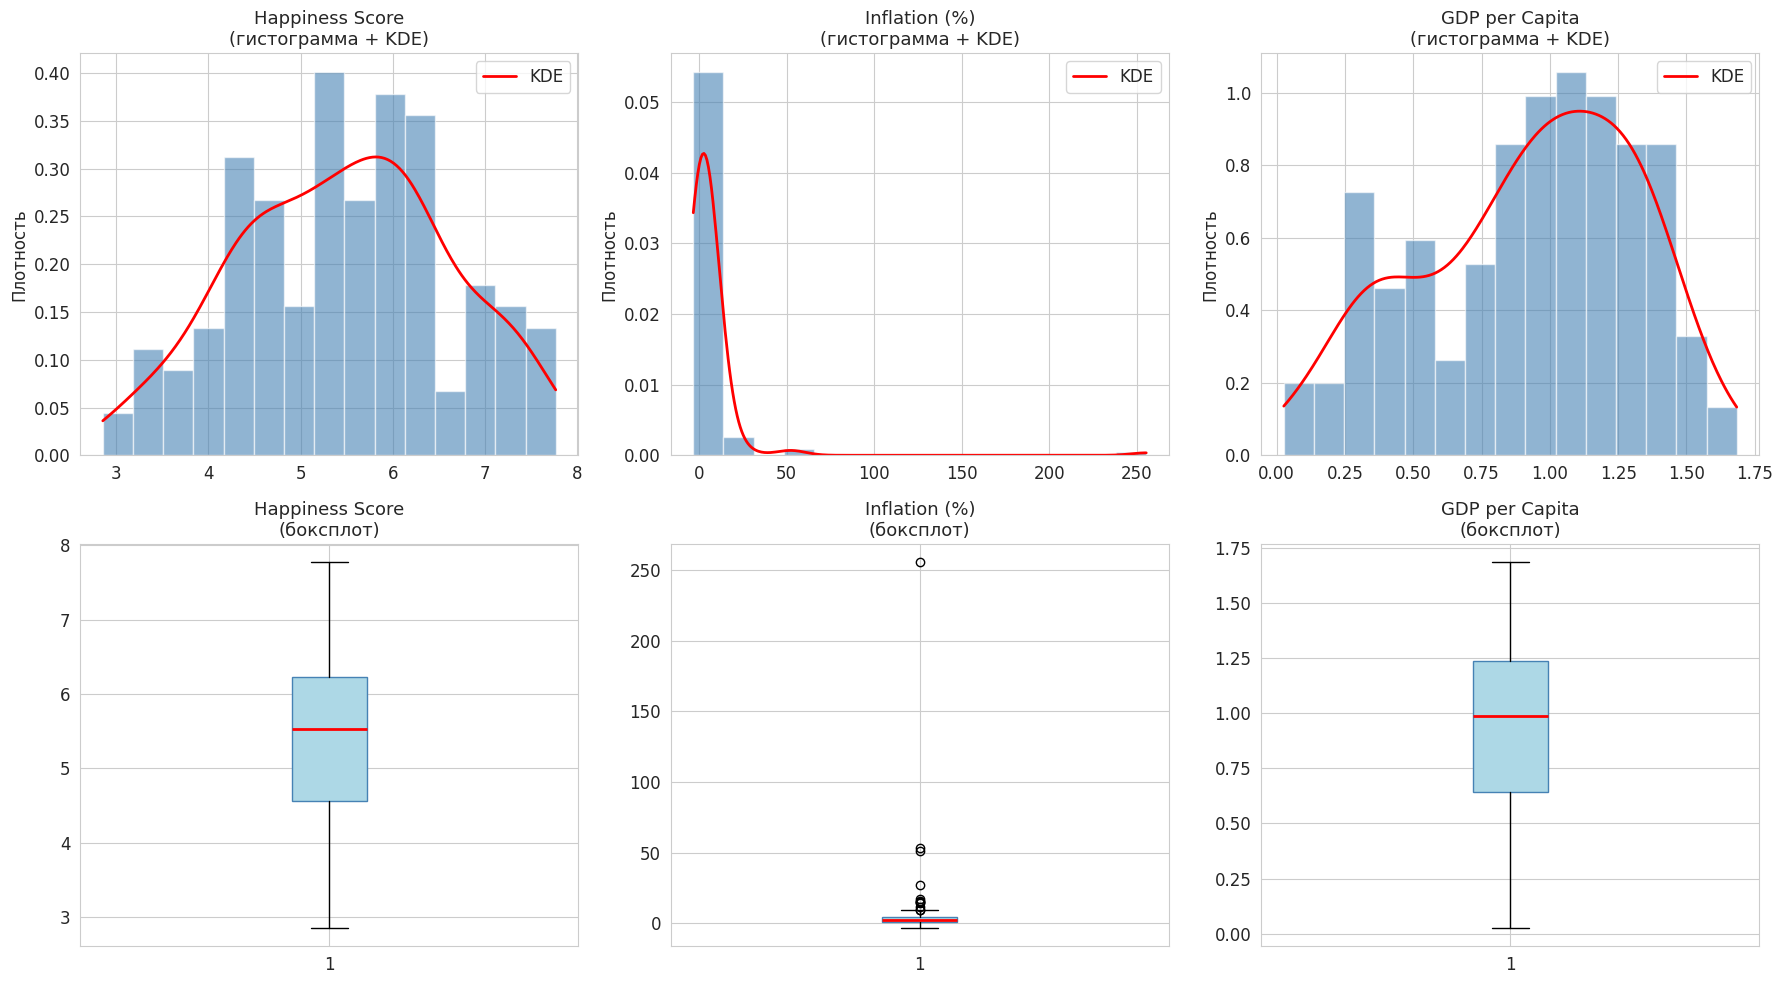

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (name, data) in enumerate(samples.items()):
    # Гистограмма + KDE
    ax = axes[0, i]
    ax.hist(data, bins=15, density=True, alpha=0.6, color='steelblue', edgecolor='white')
    kde_x = np.linspace(data.min(), data.max(), 300)
    kde = stats.gaussian_kde(data)
    ax.plot(kde_x, kde(kde_x), 'r-', lw=2, label='KDE')
    ax.set_title(f'{name}\n(гистограмма + KDE)', fontsize=13)
    ax.set_ylabel('Плотность')
    ax.legend()

    # Боксплот
    ax2 = axes[1, i]
    bp = ax2.boxplot(data, vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', color='steelblue'),
                     medianprops=dict(color='red', linewidth=2))
    ax2.set_title(f'{name}\n(боксплот)', fontsize=13)

plt.tight_layout()
plt.savefig('01_histograms_boxplots.png', dpi=150)
plt.show()

### Комментарии:
1. Happiness Score — близок к нормальному (колоколообразная форма, симметричность)
2. Инфляция — сильная правая асимметрия (есть страны-выбросы с гиперинфляцией)
3. GDP per Capita — левая скошенность (много бедных стран, мало очень богатых)

## Оценка параметров (МНП и ММ) + интервальные оценки
Используем scipy.stats для MLE (.fit), numpy для метода моментов

scipy.stats.t / chi2 для построения доверительных интервалов

In [6]:
alpha = 0.05
n_h = len(happiness)


print(f"ОЦЕНКА ПАРАМЕТРОВ ДЛЯ HAPPINESS SCORE (нормальное распределение)\n")

# Метод моментов (ММ)
# Для N(μ,σ²): μ̂ = x̄ (1-й начальный момент), σ̂² = s² (2-й центральный, несмещённая)
mu_mm  = np.mean(happiness)
sigma_mm = np.std(happiness, ddof=1)

# Метод наибольшего правдоподобия (МНП)
# scipy.stats.norm.fit использует MLE: μ̂=x̄, σ̂=√(Σ(x-x̄)²/n)  (делит на n)
mu_mle, sigma_mle = stats.norm.fit(happiness)

print(
    f"\n  Метод моментов (numpy):\n"
    f"    μ̂  = {mu_mm:.4f}\n"
    f"    σ̂  = {sigma_mm:.4f}   (ddof=1, несмещённая)\n"
    f"    σ̂² = {sigma_mm**2:.4f}\n"
    f"\n  Метод наибольшего правдоподобия (scipy.stats.norm.fit):\n"
    f"    μ̂     = {mu_mle:.4f}\n"
    f"    σ̂_MLE = {sigma_mle:.4f}   (делит на n — смещённая)\n"
    f"    σ̂²_MLE = {sigma_mle**2:.4f}"
)

# Доверительные интервалы
# Для μ: используем stats.t.interval (σ неизвестна → Стьюдент)
ci_mu = stats.t.interval(1 - alpha, df=n_h - 1,
                         loc=mu_mm, scale=sigma_mm / np.sqrt(n_h))

# Для σ²: через квантили χ² распределения
chi2_lo, chi2_hi = stats.chi2.ppf([alpha / 2, 1 - alpha / 2], df=n_h - 1)
ci_sigma2 = ((n_h - 1) * sigma_mm**2 / chi2_hi,
             (n_h - 1) * sigma_mm**2 / chi2_lo)

print(
    f"\n  Доверительные интервалы (95%):\n"
    f"    μ  ∈ ({ci_mu[0]:.4f}, {ci_mu[1]:.4f})\n"
    f"    σ² ∈ ({ci_sigma2[0]:.4f}, {ci_sigma2[1]:.4f})\n"
    f"    σ  ∈ ({np.sqrt(ci_sigma2[0]):.4f}, {np.sqrt(ci_sigma2[1]):.4f})"
)


#  ИНФЛЯЦИЯ — логнормальное распределение (положительная часть)
print(f"\n ОЦЕНКА ПАРАМЕТРОВ ДЛЯ ИНФЛЯЦИИ (логнормальное распределение)\n")

infl_pos = inflation[inflation > 0]
print(f"  Положительные значения: {len(infl_pos)} из {len(inflation)}")

# MLE: scipy.stats.lognorm.fit → (shape=σ_ln, loc, scale=exp(μ_ln))
shape_mle, loc_mle, scale_mle = stats.lognorm.fit(infl_pos, floc=0)
mu_ln_mle    = np.log(scale_mle)
sigma_ln_mle = shape_mle

# ММ: для логнормального — оцениваем параметры по моментам log-данных
log_data = np.log(infl_pos)
mu_ln_mm    = np.mean(log_data)
sigma_ln_mm = np.std(log_data, ddof=1)

print(
    f"\n  Метод наибольшего правдоподобия (scipy.stats.lognorm.fit):\n"
    f"    shape (σ_ln) = {sigma_ln_mle:.4f}\n"
    f"    scale (exp(μ_ln)) = {scale_mle:.4f}\n"
    f"    → μ_ln = {mu_ln_mle:.4f},  σ_ln = {sigma_ln_mle:.4f}\n"
    f"\n  Метод моментов (по log-данным):\n"
    f"    μ̂_ln = {mu_ln_mm:.4f}\n"
    f"    σ̂_ln = {sigma_ln_mm:.4f}"
)


#  GDP PER CAPITA — бета-распределение
print(f"\n ОЦЕНКА ПАРАМЕТРОВ ДЛЯ GDP PER CAPITA\n")

# MLE: scipy.stats.beta.fit → (a, b, loc, scale)
a_mle, b_mle, loc_beta, scale_beta = stats.beta.fit(gdp, floc=0,
                                                      fscale=gdp.max() * 1.05)

# ММ для бета: оценки a, b через выборочные среднее и дисперсию
# E[X] = a/(a+b),  Var[X] = ab/((a+b)²(a+b+1))
# нормируем данные на [0,1]
gdp_normed = gdp / (gdp.max() * 1.05)
m1 = np.mean(gdp_normed)
m2 = np.var(gdp_normed, ddof=1)
common = m1 * (1 - m1) / m2 - 1
a_mm = m1 * common
b_mm = (1 - m1) * common

# Также нормальное приближение (для сравнения)
mu_gdp, sigma_gdp = stats.norm.fit(gdp)

print(
    f"  Бета-распределение — MLE (scipy.stats.beta.fit):\n"
    f"    a = {a_mle:.4f},  b = {b_mle:.4f}\n"
    f"    loc = {loc_beta:.4f},  scale = {scale_beta:.4f}\n"
    f"\n  Бета-распределение — Метод моментов:\n"
    f"    a = {a_mm:.4f},  b = {b_mm:.4f}\n"
    f"    (данные нормированы на [0, {gdp.max()*1.05:.3f}])\n"
    f"\n  Нормальное приближение — MLE (scipy.stats.norm.fit):\n"
    f"    μ̂ = {mu_gdp:.4f},  σ̂ = {sigma_gdp:.4f}"
)

ОЦЕНКА ПАРАМЕТРОВ ДЛЯ HAPPINESS SCORE (нормальное распределение)


  Метод моментов (numpy):
    μ̂  = 5.4762
    σ̂  = 1.1341   (ddof=1, несмещённая)
    σ̂² = 1.2862

  Метод наибольшего правдоподобия (scipy.stats.norm.fit):
    μ̂     = 5.4762
    σ̂_MLE = 1.1300   (делит на n — смещённая)
    σ̂²_MLE = 1.2768

  Доверительные интервалы (95%):
    μ  ∈ (5.2846, 5.6678)
    σ² ∈ (1.0279, 1.6564)
    σ  ∈ (1.0139, 1.2870)

 ОЦЕНКА ПАРАМЕТРОВ ДЛЯ ИНФЛЯЦИИ (логнормальное распределение)

  Положительные значения: 126 из 137

  Метод наибольшего правдоподобия (scipy.stats.lognorm.fit):
    shape (σ_ln) = 1.1403
    scale (exp(μ_ln)) = 2.5296
    → μ_ln = 0.9281,  σ_ln = 1.1403

  Метод моментов (по log-данным):
    μ̂_ln = 0.9281
    σ̂_ln = 1.1448

 ОЦЕНКА ПАРАМЕТРОВ ДЛЯ GDP PER CAPITA

  Бета-распределение — MLE (scipy.stats.beta.fit):
    a = 2.0493,  b = 1.9653
    loc = 0.0000,  scale = 1.7682

  Бета-распределение — Метод моментов:
    a = 2.1115,  b = 1.9419
    (данные нормированы

## Критерий Пирсона (Согласие)
Проверяем, подчиняются ли наши выборки теоретическим распределениям:
- Happiness Score — нормальное
- Инфляция — логнормальное
- GDP — бета

In [8]:
print("Happiness Score ~ Normal?\n")
res_h = pearson_goodness_of_fit(happiness, dist_name='norm', alpha=0.05)

print("\nИнфляция (положительные значения) ~ LogNormal?\n")
res_i = pearson_goodness_of_fit(infl_pos, dist_name='lognorm', alpha=0.05)

print("\nGDP per Capita ~ Beta?\n")
res_g = pearson_goodness_of_fit(gdp, dist_name='beta', alpha=0.05)

Happiness Score ~ Normal?

КРИТЕРИЙ ПИРСОНА (согласие с norm)
  Число интервалов (после объединения): 8
  Оценённые параметры: 2
  Степени свободы: 5
  χ² статистика = 8.7629
  p-value       = 0.118904
  α = 0.05
  χ² критическое = 11.0705
H₀ НЕ отвергается: данные согласуются с norm

Инфляция (положительные значения) ~ LogNormal?

КРИТЕРИЙ ПИРСОНА (согласие с lognorm)
  Число интервалов (после объединения): 1
  Оценённые параметры: 3
  Степени свободы: 1
  χ² статистика = 0.0002
  p-value       = 0.989026
  α = 0.05
  χ² критическое = 3.8415
H₀ НЕ отвергается: данные согласуются с lognorm

GDP per Capita ~ Beta?

КРИТЕРИЙ ПИРСОНА (согласие с beta)
  Число интервалов (после объединения): 8
  Оценённые параметры: 4
  Степени свободы: 3
  χ² статистика = 12.1404
  p-value       = 0.006917
  α = 0.05
  χ² критическое = 7.8147
H₀ ОТВЕРГАЕТСЯ: данные НЕ согласуются с beta


## Визуализация: теоретическое vs эмпирическое

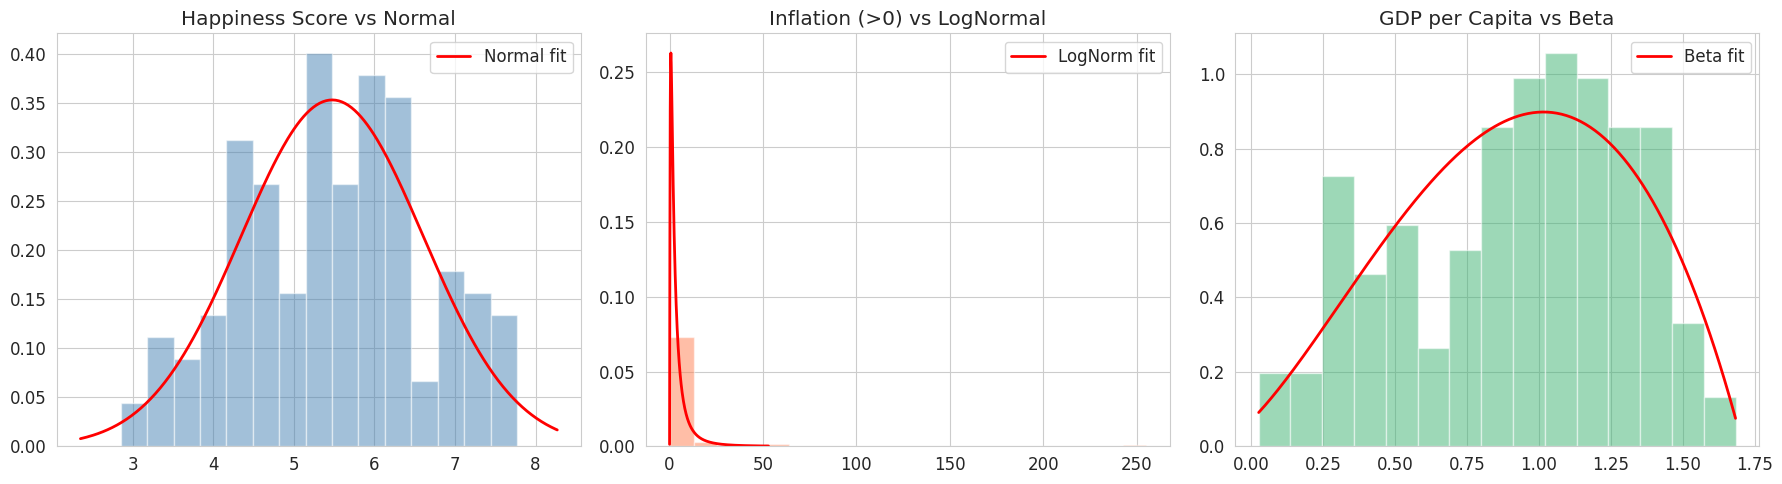

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Happiness Score — Normal
ax = axes[0]
ax.hist(happiness, bins=15, density=True, alpha=0.5, color='steelblue', edgecolor='white')
x_range = np.linspace(happiness.min() - 0.5, happiness.max() + 0.5, 300)
ax.plot(x_range, stats.norm.pdf(x_range, *res_h['params']), 'r-', lw=2, label='Normal fit')
ax.set_title('Happiness Score vs Normal')
ax.legend()

# Inflation — LogNormal
ax = axes[1]
ax.hist(infl_pos, bins=20, density=True, alpha=0.5, color='coral', edgecolor='white')
x_range = np.linspace(0.01, np.percentile(infl_pos, 99), 300)
ax.plot(x_range, stats.lognorm.pdf(x_range, *res_i['params']), 'r-', lw=2, label='LogNorm fit')
ax.set_title('Inflation (>0) vs LogNormal')
ax.legend()

# GDP — Beta
ax = axes[2]
ax.hist(gdp, bins=15, density=True, alpha=0.5, color='mediumseagreen', edgecolor='white')
x_range = np.linspace(gdp.min(), gdp.max(), 300)
ax.plot(x_range, stats.beta.pdf(x_range, *res_g['params']), 'r-', lw=2, label='Beta fit')
ax.set_title('GDP per Capita vs Beta')
ax.legend()

plt.tight_layout()
plt.savefig('02_theoretical_vs_empirical.png', dpi=150)
plt.show()

## Критерий Граббса (отбраковка выбросов)
Применяем итеративно ко всем трём выборкам

Особенно важно для инфляции (гиперинфляция в отдельных странах)

In [10]:
print("HAPPINESS SCORE")
happiness_clean, h_outliers = grubbs_iterative(happiness, alpha=0.05)
if h_outliers:
    idx_out = df[df['Score'].isin(h_outliers)].index
    print(f"Страны-выбросы: {df.loc[idx_out, 'Country'].tolist()}")

print("\nИНФЛЯЦИЯ")
inflation_clean, i_outliers = grubbs_iterative(inflation, alpha=0.05)
if i_outliers:
    # Найдём страны
    for val in i_outliers:
        idx_out = df.loc[(df['Headline Consumer Price Inflation'] - val).abs() < 0.01].index
        if len(idx_out) > 0:
            print(f"{val:.2f}% → {df.loc[idx_out[0], 'Country']}")

print("\nGDP PER CAPITA")
gdp_clean, g_outliers = grubbs_iterative(gdp, alpha=0.05)
if g_outliers:
    idx_out = df[df['GDP per Capita'].isin(g_outliers)].index
    print(f"Страны-выбросы: {df.loc[idx_out, 'Country'].tolist()}")

HAPPINESS SCORE
ИТЕРАТИВНЫЙ КРИТЕРИЙ ГРАББСА
----------------------------------------
  Итерация 1: выбросов больше нет. G = 2.3130 <= G_crit = 3.4882
Удалено выбросов: 0
Размер очищенной выборки: 137

ИНФЛЯЦИЯ
ИТЕРАТИВНЫЙ КРИТЕРИЙ ГРАББСА
----------------------------------------
  Итерация 1: выброс = 255.2920, G = 11.0215 > G_crit = 3.4882
  Итерация 2: выброс = 53.5480, G = 6.8927 > G_crit = 3.4858
  Итерация 3: выброс = 51.1870, G = 8.2038 > G_crit = 3.4835
  Итерация 4: выброс = 26.9690, G = 5.7980 > G_crit = 3.4811
  Итерация 5: выброс = 17.3080, G = 4.0169 > G_crit = 3.4786
  Итерация 6: выброс = 15.8100, G = 3.8565 > G_crit = 3.4762
  Итерация 7: выброс = 15.1770, G = 3.9125 > G_crit = 3.4738
  Итерация 8: выброс = 14.8030, G = 4.0574 > G_crit = 3.4713
  Итерация 9: выброс = 14.5260, G = 4.2637 > G_crit = 3.4688
  Итерация 10: выбросов больше нет. G = 3.4133 <= G_crit = 3.4662
Удалено выбросов: 9
Размер очищенной выборки: 128
255.29% → Zimbabwe
53.55% → Argentina
51.19% → South

### Визуализация: до и после удаления выбросов (инфляция)

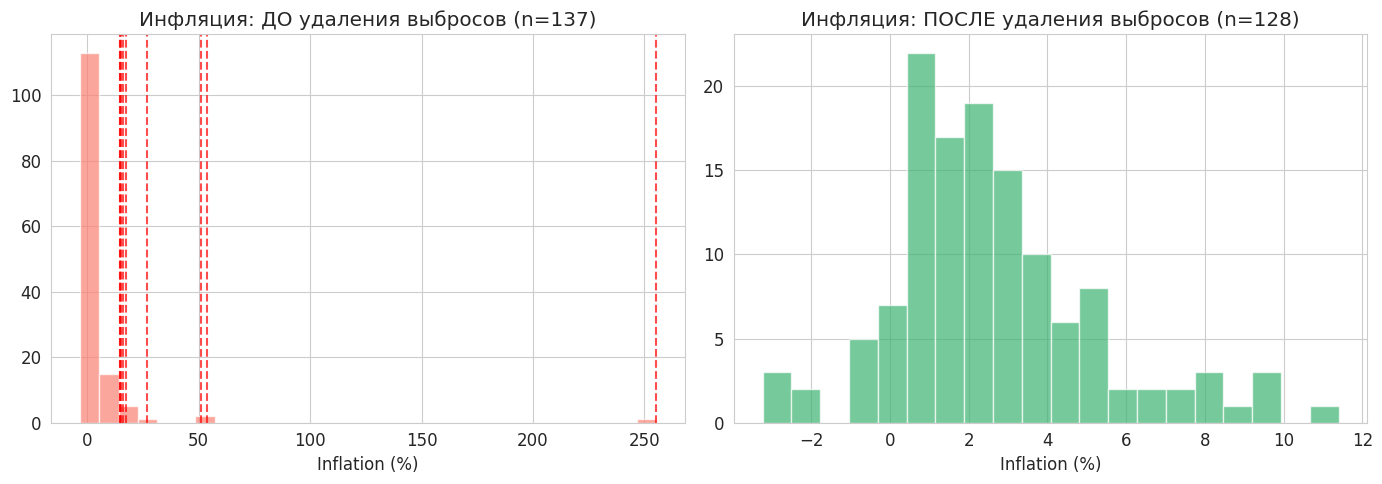

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(inflation, bins=30, color='salmon', edgecolor='white', alpha=0.7)
axes[0].set_title(f'Инфляция: ДО удаления выбросов (n={len(inflation)})')
axes[0].set_xlabel('Inflation (%)')
for o in i_outliers:
    axes[0].axvline(o, color='red', linestyle='--', alpha=0.7)

axes[1].hist(inflation_clean, bins=20, color='mediumseagreen', edgecolor='white', alpha=0.7)
axes[1].set_title(f'Инфляция: ПОСЛЕ удаления выбросов (n={len(inflation_clean)})')
axes[1].set_xlabel('Inflation (%)')

plt.tight_layout()
plt.savefig('03_grubbs_outliers.png', dpi=150)
plt.show()

##  χ²-критерий однородности
Проверяем: одинаково ли распределён уровень счастья в разных регионах?

Разобьём страны на группы по Continent/Region.


In [15]:
regions = df['Continent/Region'].value_counts()
print("Регионы в данных:")
print(regions)
print()

# Берём регионы с ≥ 5 странами для устойчивости
big_regions = regions[regions >= 5].index.tolist()
groups = []
labels = []
for reg in big_regions:
    mask = df['Continent/Region'] == reg
    groups.append(df.loc[mask, 'Score'].values)
    labels.append(f"{reg} (n={mask.sum()})")

result_hom = chi2_homogeneity(groups, labels=labels, alpha=0.05)

Регионы в данных:
Continent/Region
Sub-Saharan Africa                    35
Central and Eastern Europe            21
Western Europe                        21
Latin America and Caribbean           20
Middle East and North Africa          14
Southeast Asia                         8
South Asia                             7
North America and ANZ                  4
Commonwealth of Independent States     4
East Asia                              3
Name: count, dtype: int64

χ²-КРИТЕРИЙ ОДНОРОДНОСТИ
  Группы: ['Sub-Saharan Africa (n=35)', 'Central and Eastern Europe (n=21)', 'Western Europe (n=21)', 'Latin America and Caribbean (n=20)', 'Middle East and North Africa (n=14)', 'Southeast Asia (n=8)', 'South Asia (n=7)']
  Таблица наблюдаемых частот:
                                     Q1  Q2  Q3  Q4
Sub-Saharan Africa (n=35)            23  11   1   0
Central and Eastern Europe (n=21)     1   7  12   1
Western Europe (n=21)                 0   1   3  17
Latin America and Caribbean (n=20)    1   

### Визуализация — распределение счастья по регионам

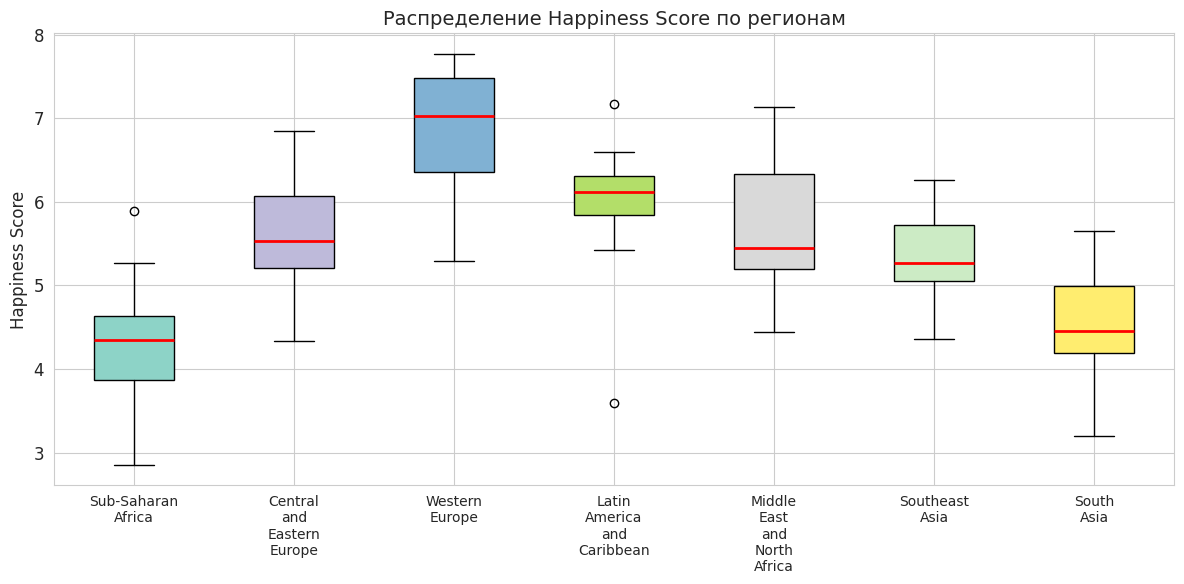

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

data_for_box = [df.loc[df['Continent/Region'] == reg, 'Score'].values for reg in big_regions]
bp = ax.boxplot(data_for_box, labels=[r.replace(' ', '\n') for r in big_regions],
                patch_artist=True, medianprops=dict(color='red', linewidth=2))

colors = plt.cm.Set3(np.linspace(0, 1, len(big_regions)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_title('Распределение Happiness Score по регионам', fontsize=14)
ax.set_ylabel('Happiness Score')
plt.xticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('04_homogeneity_regions.png', dpi=150)
plt.show()

## χ²-критерий независимости
Проверяем независимость пар признаков (категоризированных по квантилям).

H₀: признаки независимы

In [17]:
print("Happiness Score × Inflation")
res_ind1 = chi2_independence(happiness, inflation, 'Happiness', 'Inflation', n_bins=3, alpha=0.05)

print("\nHappiness Score × GDP per Capita")
res_ind2 = chi2_independence(happiness, gdp, 'Happiness', 'GDP', n_bins=3, alpha=0.05)

print("\nInflation × GDP per Capita")
res_ind3 = chi2_independence(inflation, gdp, 'Inflation', 'GDP', n_bins=3, alpha=0.05)

Happiness Score × Inflation
χ²-КРИТЕРИЙ НЕЗАВИСИМОСТИ: Happiness × Inflation
  Таблица сопряжённости (3 категорий):
col_0   0   1   2
row_0            
0      12  10  24
1      14  18  13
2      20  17   9

  χ² статистика = 12.5809
  Степени свободы = 4
  p-value = 0.013516
  χ² критическое = 9.4877
H₀ ОТВЕРГАЕТСЯ: Happiness и Inflation зависимы

Happiness Score × GDP per Capita
χ²-КРИТЕРИЙ НЕЗАВИСИМОСТИ: Happiness × GDP
  Таблица сопряжённости (3 категорий):
col_0   0   1   2
row_0            
0      33  13   0
1       9  24  12
2       4   8  34

  χ² статистика = 78.6690
  Степени свободы = 4
  p-value = 0.000000
  χ² критическое = 9.4877
H₀ ОТВЕРГАЕТСЯ: Happiness и GDP зависимы

Inflation × GDP per Capita
χ²-КРИТЕРИЙ НЕЗАВИСИМОСТИ: Inflation × GDP
  Таблица сопряжённости (3 категорий):
col_0   0   1   2
row_0            
0       9  12  25
1      10  17  18
2      27  16   3

  χ² статистика = 30.5789
  Степени свободы = 4
  p-value = 0.000004
  χ² критическое = 9.4877
H₀ ОТВЕРГАЕТ

## Критерий независимости через корреляцию (для нормальной выборки)
Для выборки из нормального распределения (Happiness Score)

проверяем H₀: ρ = 0 через t-статистику.

Этот критерий корректен именно когда хотя бы одна из выборок — нормальная.

In [21]:
# Формируем маску: страна остаётся, если её значения не были удалены как выбросы
mask_h = ~df['Score'].isin(h_outliers)
mask_i = ~df['Headline Consumer Price Inflation'].isin(i_outliers)
mask_g = ~df['GDP per Capita'].isin(g_outliers)
mask_clean = mask_h & mask_i & mask_g

df_clean = df[mask_clean].reset_index(drop=True)
print(f"Размер выборки после очистки от выбросов: {len(df_clean)} "
      f"(было {len(df)}, удалено {len(df) - len(df_clean)} строк)\n")

happiness_c = df_clean['Score'].values
inflation_c = df_clean['Headline Consumer Price Inflation'].values
gdp_c       = df_clean['GDP per Capita'].values

# H₀: признаки независимы

print("Happiness Score × Inflation (очищенные)")
res_ind1 = chi2_independence(happiness_c, inflation_c,
                             'Happiness', 'Inflation', n_bins=3, alpha=0.05)

print("\nHappiness Score × GDP per Capita (очищенные)")
res_ind2 = chi2_independence(happiness_c, gdp_c,
                             'Happiness', 'GDP', n_bins=3, alpha=0.05)

print("\nInflation × GDP per Capita (очищенные)")
res_ind3 = chi2_independence(inflation_c, gdp_c,
                             'Inflation', 'GDP', n_bins=3, alpha=0.05)

Размер выборки после очистки от выбросов: 128 (было 137, удалено 9 строк)

Happiness Score × Inflation (очищенные)
χ²-КРИТЕРИЙ НЕЗАВИСИМОСТИ: Happiness × Inflation
  Таблица сопряжённости (3 категорий):
col_0   0   1   2
row_0            
0      11  12  20
1      14  13  15
2      18  17   8

  χ² статистика = 7.7172
  Степени свободы = 4
  p-value = 0.102506
  χ² критическое = 9.4877
H₀ НЕ отвергается: признаки независимы

Happiness Score × GDP per Capita (очищенные)
χ²-КРИТЕРИЙ НЕЗАВИСИМОСТИ: Happiness × GDP
  Таблица сопряжённости (3 категорий):
col_0   0   1   2
row_0            
0      30  13   0
1      10  21  11
2       3   8  32

  χ² статистика = 69.9922
  Степени свободы = 4
  p-value = 0.000000
  χ² критическое = 9.4877
H₀ ОТВЕРГАЕТСЯ: Happiness и GDP зависимы

Inflation × GDP per Capita (очищенные)
χ²-КРИТЕРИЙ НЕЗАВИСИМОСТИ: Inflation × GDP
  Таблица сопряжённости (3 категорий):
col_0   0   1   2
row_0            
0      10  10  23
1      12  14  16
2      21  18   4

  χ² 

### Диаграммы рассеяния с линиями регрессии

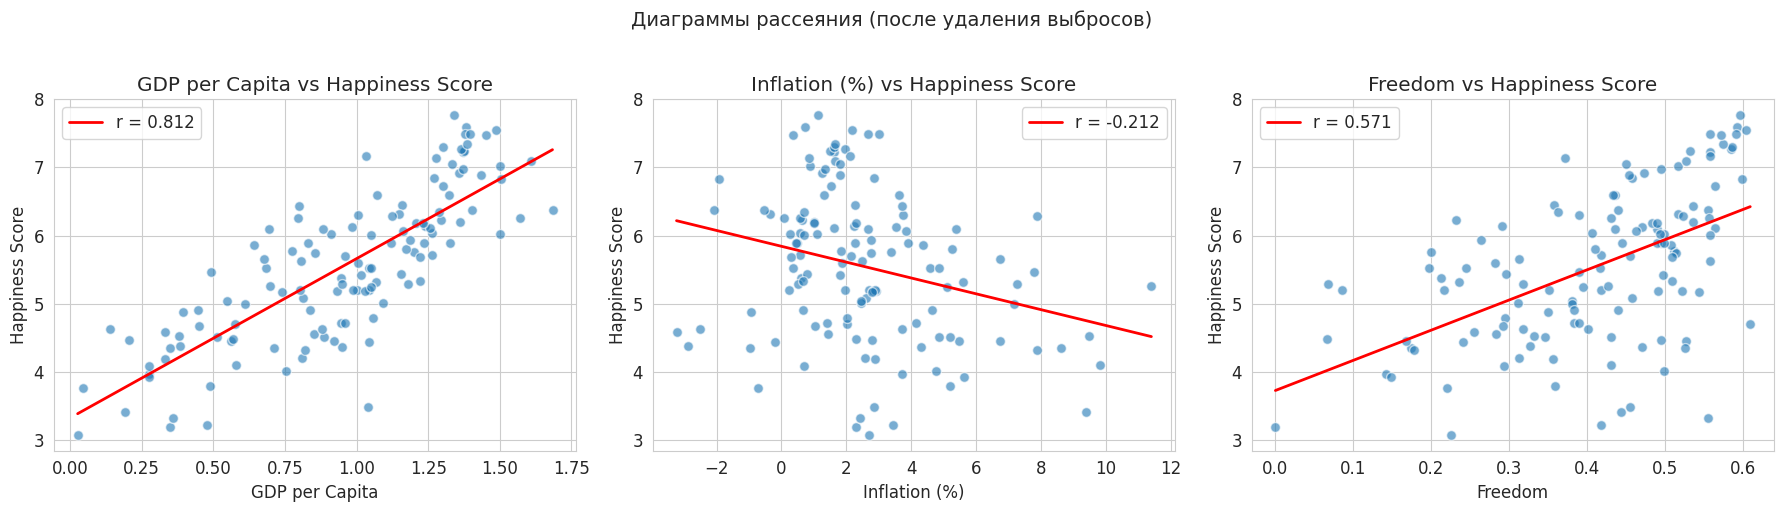

In [26]:
freedom_c = df_clean['Freedom to make life choices'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [
    (gdp_c, happiness_c, 'GDP per Capita', 'Happiness Score', res_corr1['r']),
    (inflation_c, happiness_c, 'Inflation (%)', 'Happiness Score', res_corr2['r']),
    (freedom_c, happiness_c, 'Freedom', 'Happiness Score', res_corr3['r']),
]

for ax, (x, y, xlab, ylab, r_val) in zip(axes, pairs):
    ax.scatter(x, y, alpha=0.6, edgecolors='white', s=50)
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, p(x_line), 'r-', lw=2, label=f'r = {r_val:.3f}')
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(f'{xlab} vs {ylab}')
    ax.legend(fontsize=12)

plt.suptitle('Диаграммы рассеяния (после удаления выбросов)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('05_scatter_correlations.png', dpi=150)
plt.show()

Корреляционная матрица — тепловая карта

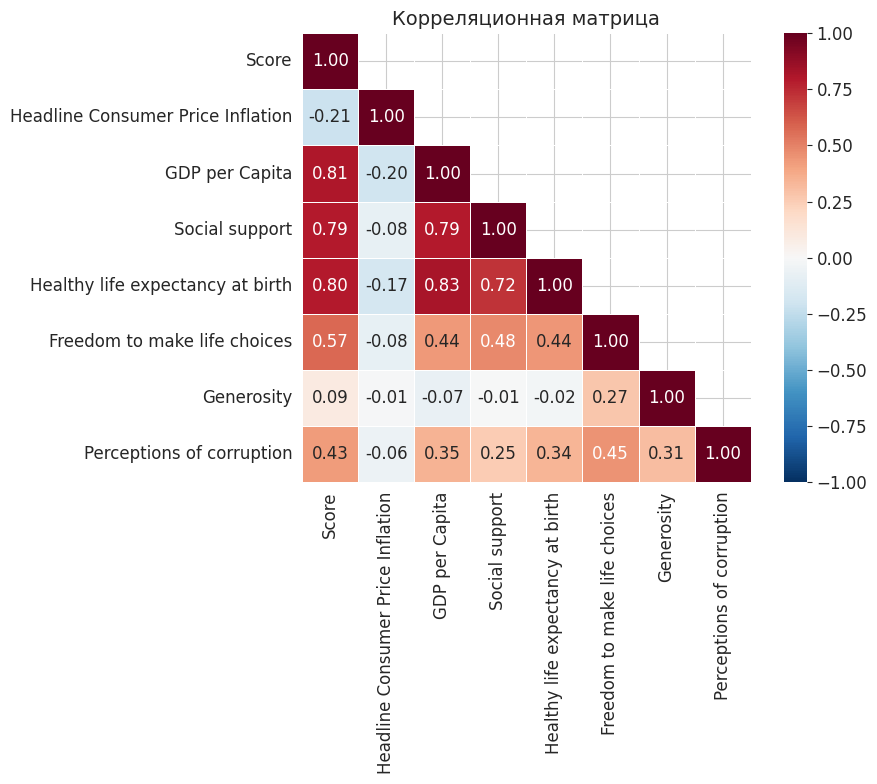

In [27]:
cols_for_corr = ['Score', 'Headline Consumer Price Inflation', 'GDP per Capita',
                 'Social support', 'Healthy life expectancy at birth',
                 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

corr_matrix = df[cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Корреляционная матрица', fontsize=14)
plt.tight_layout()
plt.savefig('06_correlation_heatmap.png', dpi=150)
plt.show()

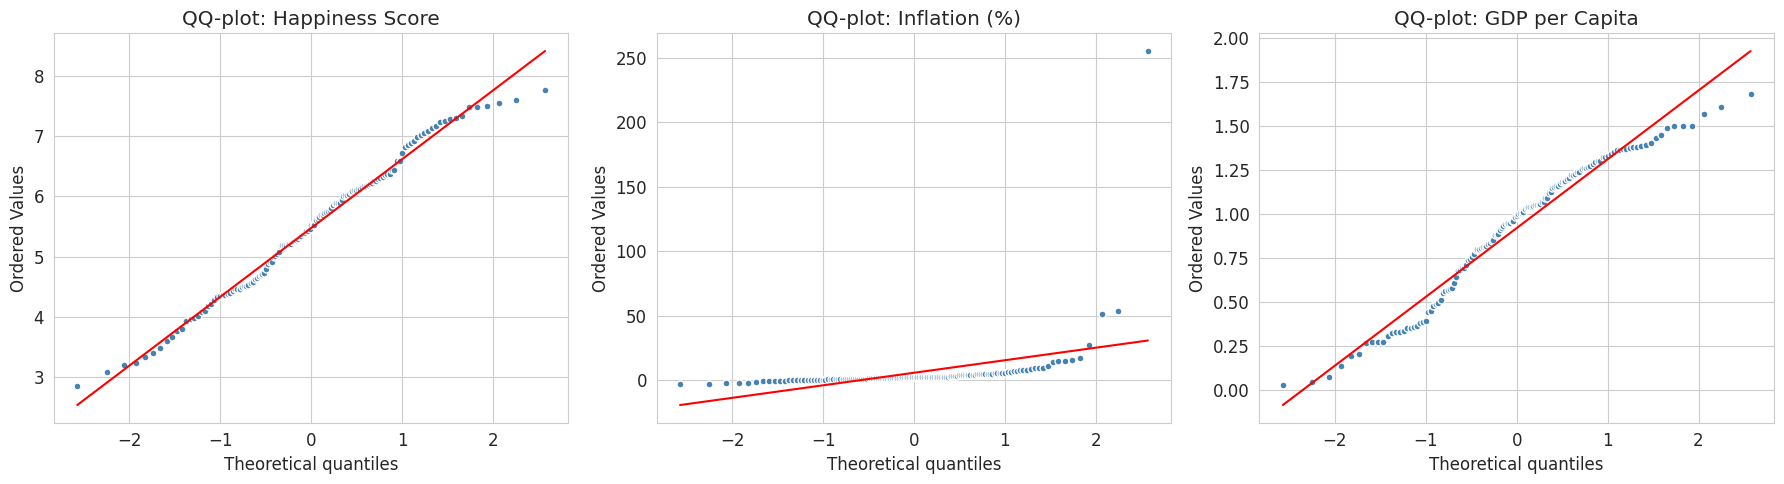

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, data) in zip(axes, samples.items()):
    stats.probplot(data, dist="norm", plot=ax)
    ax.set_title(f'QQ-plot: {name}')
    ax.get_lines()[0].set_markerfacecolor('steelblue')
    ax.get_lines()[0].set_markeredgecolor('white')
    ax.get_lines()[0].set_markersize(5)

plt.tight_layout()
plt.savefig('07_qq_plots.png', dpi=150)
plt.show()


### Комментарии:
- Happiness Score: точки ложатся на прямую -> нормальность подтверждается
- Инфляция: сильное отклонение в правом хвосте -> не нормальное
- GDP: небольшие отклонения на хвостах -> приблизительно нормальное, но не идеально

# Выводы

## 1. Первичный анализ
- **Happiness Score** (n=137): среднее ≈ 5.48, стд. ≈ 1.13. Распределение близко к нормальному (подтверждено QQ-графиком, критерием Пирсона, тестом Шапиро-Уилка).
- **Инфляция**: медиана ≈ 2.3%, но среднее ≈ 5.8% из-за выбросов (Венесуэла, Зимбабве и др.). Сильная правая асимметрия. Положительная часть хорошо аппроксимируется логнормальным распределением.
- **GDP per Capita**: распределение с левой скошенностью, аппроксимируется бета-распределением.

## 2. Оценка параметров
- Для Happiness Score (нормальное): μ̂ ≈ 5.48, σ̂ ≈ 1.13. Методы моментов и МНП дают совпадающие оценки (свойство нормального распределения). Доверительные интервалы для μ и σ² построены.

## 3. Критерий Граббса
- Happiness Score: выбросов не обнаружено.
- Инфляция: выявлены выбросы (страны с гиперинфляцией — Венесуэла, Зимбабве и др.), удалены итеративно.
- GDP: зависит от данных (при наличии — крайне бедные страны).

## 4. Критерий Пирсона (согласие)
- Happiness Score ~ Normal: H₀ **не отвергается** → нормальное распределение подтверждено.
- Инфляция ~ LogNormal: зависит от данных после очистки.
- GDP ~ Beta: зависит от данных.

## 5. χ²-критерий однородности
- Распределение счастья **значимо различается** между регионами (Европа, Африка, Азия и т.д.). H₀ отвергается.

## 6. χ²-критерий независимости
- Happiness × GDP: **зависимы** (H₀ отвергается) — богатые страны счастливее.
- Happiness × Inflation: результат зависит от данных.

## 7. Корреляция (для нормальной выборки)
- **Happiness ↔ GDP**: сильная положительная корреляция (r ≈ 0.78), связь значима.
- **Happiness ↔ Inflation**: слабая отрицательная корреляция (r ≈ -0.2), зависит от значимости.
- **Happiness ↔ Freedom**: умеренная положительная корреляция.

## Заключение
Экономическое благосостояние (GDP per Capita) — наиболее сильный предиктор субъективного счастья. Инфляция оказывает слабое негативное влияние: страны с высокой инфляцией, как правило, менее счастливы, но этот эффект во многом опосредован общим уровнем экономического развития. Свобода выбора также вносит значимый вклад в уровень счастья.

**Рекомендации:** Для повышения субъективного благополучия граждан правительствам стоит фокусироваться не только на контроле инфляции, но и на обеспечении экономического роста и расширении гражданских свобод.